## Script for statistics of classifier chains ensemble


In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import utils
import os
from sklearn.metrics import jaccard_score

In [2]:
#setting filepaths of the results

pi_results_filepath = "../prediction_results/PI_results/PI_"

nnrti_results_filepath = "../prediction_results/NNRTI_results/NNRTI_"

nrti_results_filepath = "../prediction_results/NRTI_results/NRTI_"

ini_results_filepath = "../prediction_results/INI_results/INI_"



#creating lists with filepaths for later visualisation
filepath_list = [pi_results_filepath, nnrti_results_filepath, nrti_results_filepath, ini_results_filepath]




#setting filepaths the datasets

pi_results_filepath_ml = "../prediction_results/PI_results/"

nnrti_results_filepath_ml = "../prediction_results/NNRTI_results/"

nrti_results_filepath_ml = "../prediction_results/NRTI_results/"

ini_results_filepath_ml = "../prediction_results/INI_results/"



#creating lists with filepaths for later visualisation
filepath_list_ml = [pi_results_filepath_ml, nnrti_results_filepath_ml, nrti_results_filepath_ml, ini_results_filepath_ml]



In [3]:
filename = "Classifier_Chain_ensemble/"


for path in filepath_list:

    chains = os.listdir(path + filename)
    for chain in chains:
        print(path+filename+chain)

../prediction_results/PI_results/PI_Classifier_Chain_ensemble/Ensemble_0.csv
../prediction_results/PI_results/PI_Classifier_Chain_ensemble/Ensemble_1.csv
../prediction_results/PI_results/PI_Classifier_Chain_ensemble/Ensemble_2.csv
../prediction_results/PI_results/PI_Classifier_Chain_ensemble/Ensemble_3.csv
../prediction_results/NNRTI_results/NNRTI_Classifier_Chain_ensemble/Ensemble_0.csv
../prediction_results/NNRTI_results/NNRTI_Classifier_Chain_ensemble/Ensemble_1.csv
../prediction_results/NNRTI_results/NNRTI_Classifier_Chain_ensemble/Ensemble_2.csv
../prediction_results/NNRTI_results/NNRTI_Classifier_Chain_ensemble/Ensemble_3.csv
../prediction_results/NRTI_results/NRTI_Classifier_Chain_ensemble/Ensemble_0.csv
../prediction_results/NRTI_results/NRTI_Classifier_Chain_ensemble/Ensemble_1.csv
../prediction_results/NRTI_results/NRTI_Classifier_Chain_ensemble/Ensemble_2.csv
../prediction_results/NRTI_results/NRTI_Classifier_Chain_ensemble/Ensemble_3.csv
../prediction_results/INI_results/IN

In [22]:
files = ["Binary_Relevance_MOC_prediction.csv", "Binary_Relevance_homebrew_prediction.csv", "Classifier_Chain_homebrew_prediction.csv"]

sub_accs = {}



for path in filepath_list:

    acc_list = []

    for file in files:
        results = pd.read_csv(path + file)

        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        true_labels = results.filter(regex="True_*")
        pred_labels = results.filter(regex="Pred_*")

        sub_acc = utils.subset_acc(pred_labels, true_labels, nan_mode="ignore")

        acc_list.append(sub_acc)

    sub_accs.update({path.split("/")[-1].strip("_"):acc_list})



print(sub_accs)

filename = "Classifier_Chain_ensemble/"

ensemble_accs = {}


for path in filepath_list:

    chains = os.listdir(path + filename)

    chain_list = []
    chain_acc_list = []

    for chain in chains:
        #print(path+filename+chain)


        results = pd.read_csv(path+filename+chain)


        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)


        true_labels = results.filter(regex="True_*")
        pred_labels = results.filter(regex="Pred_*")

        #print(true_labels == true_labels_old)
        #print(pred_labels == pred_labels_old)


        chain_list.append(pred_labels)
        sub_acc = utils.subset_acc(pred_labels, true_labels, nan_mode="ignore")

        print(jaccard_score(true_labels, pred_labels, ))

        chain_acc_list.append(sub_acc)

    columns = chain_list[0].columns.values.tolist()

    ave_chain = (np.median(np.array(chain_list), axis=0) > 0.5) * 1

    ave_chain_df = pd.DataFrame(ave_chain, columns=columns)

    #true_labels = ave_chain_df.filter(regex="True_*")
    pred_labels = ave_chain_df

    sub_acc = utils.subset_acc(pred_labels, true_labels, nan_mode="ignore")

    chain_acc_list.append(sub_acc)

    ensemble_accs.update({path.split("/")[-1].strip("_"):chain_acc_list})

#models = ["", "RandomForest_", "XGBoost_", "CatBoost_"]


#print(sub_accs)
print(ensemble_accs)
#df_sub_accs = pd.DataFrame(sub_accs)



{'PI': [0.6578171091445427, 0.7117572692793932, 0.706700379266751], 'NNRTI': [0.6896551724137931, 0.8253968253968254, 0.8333333333333334], 'NRTI': [0.5732368896925859, 0.6033519553072626, 0.6131284916201117], 'INI': [0.6274509803921569, 0.7944664031620553, 0.8102766798418972]}


C:\Users\flori\anaconda3\Lib\site-packages\sklearn\utils\_array_api.py:390: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype, copy=copy, casting=casting)


ValueError: Input y_true contains NaN.

In [4]:
df_sub_accs = pd.DataFrame(sub_accs)
df_ensemble_accs = pd.DataFrame(ensemble_accs)


In [28]:
avg = 0
for i in range(4):
    avg += ensemble_accs["PI"][i]

print(avg/4)

0.7029077117572693


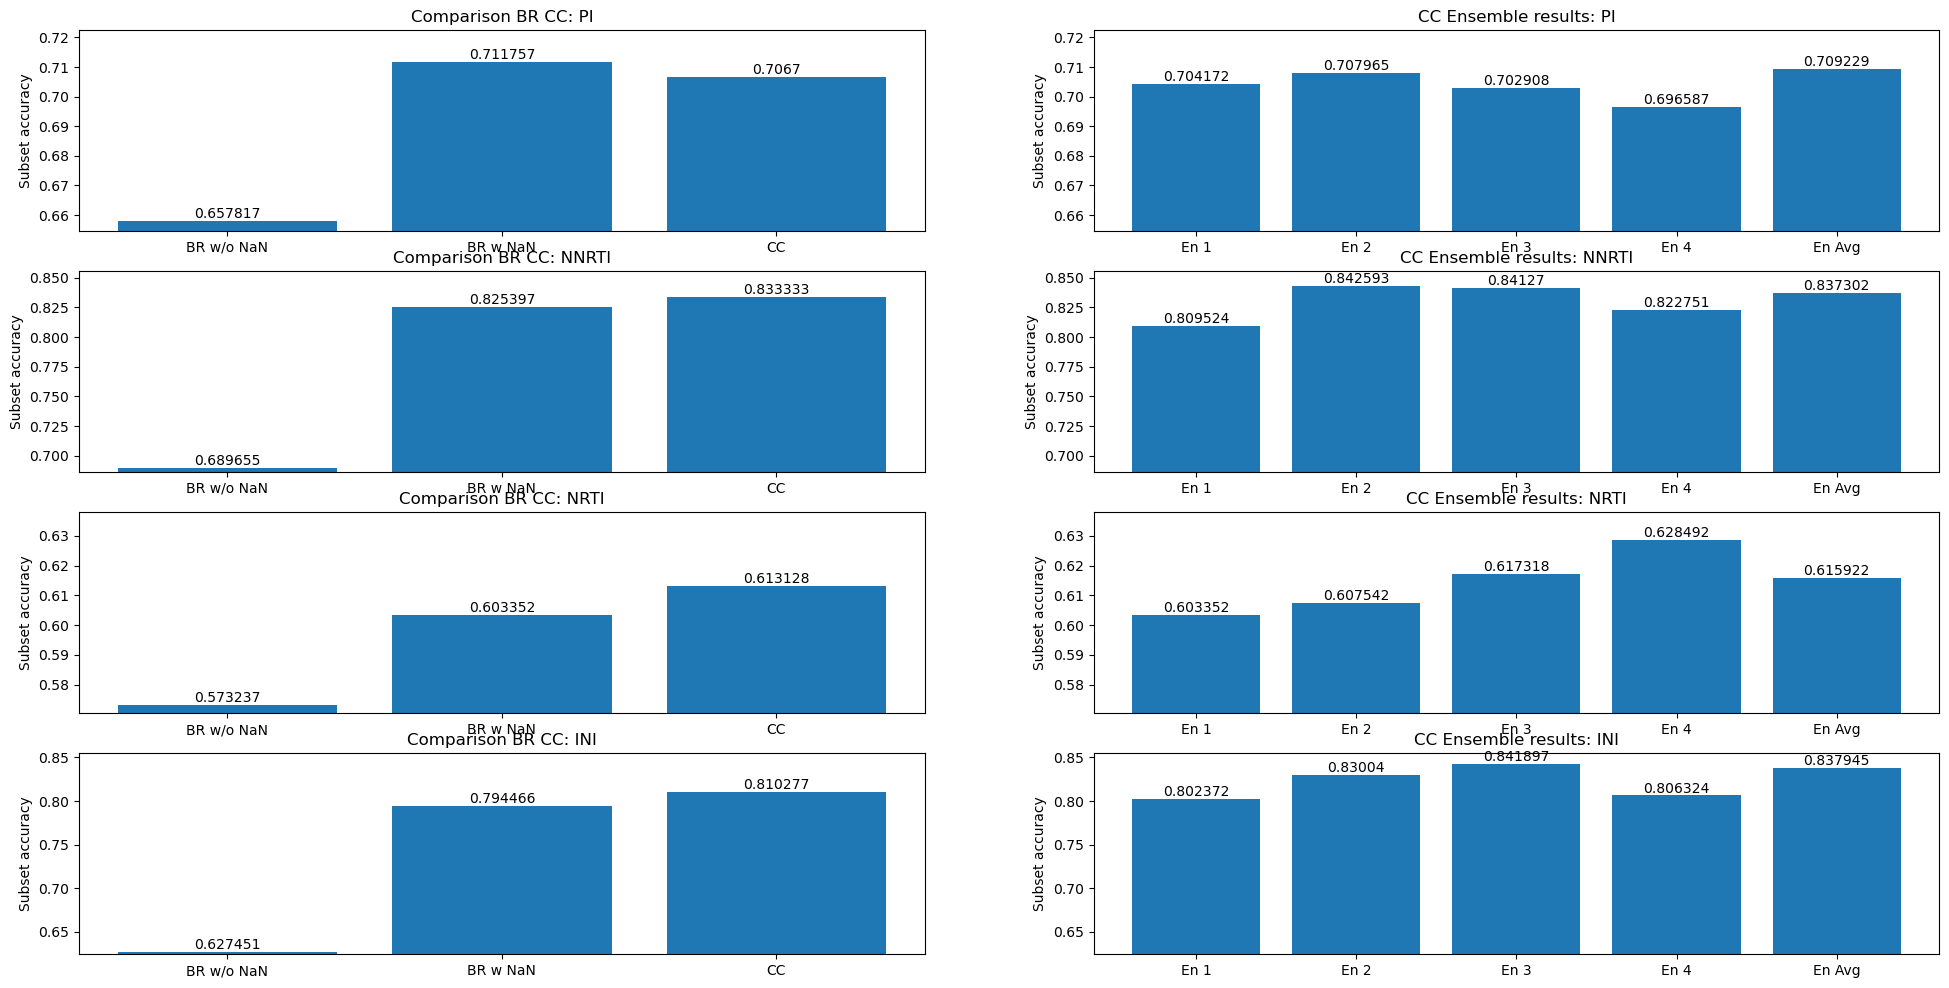

In [5]:
models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC"]
ensemble_labels = ["En 1", "En 2", "En 3", "En 4", "En Avg"]

fig, axs = plt.subplots(4, 2, figsize=(24, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs.columns.values.tolist()):

    j = 2 * i

    #print(axs[i])
    #print(i)

    p = axs[j].bar(models_w_TabPFN, df_sub_accs[drug])

    axs[j].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[j].set_ylabel('Subset accuracy')
    axs[j].set_ylim(max(0, min(df_sub_accs[drug].min(), df_ensemble_accs[drug].min())* 0.995), min(1.0, max(df_sub_accs[drug].max(), df_ensemble_accs[drug].max())  * 1.015))
    axs[j].set_title('Comparison BR CC: ' + drug)


    p2 = axs[j+1].bar(ensemble_labels, df_ensemble_accs[drug])

    axs[j+1].bar_label(p2, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[j+1].set_ylabel('Subset accuracy')
    axs[j+1].set_ylim(max(0, min(df_sub_accs[drug].min(), df_ensemble_accs[drug].min())* 0.995), min(1.0, max(df_sub_accs[drug].max(), df_ensemble_accs[drug].max())  * 1.015))
    axs[j+1].set_title('CC Ensemble results: ' + drug)


plt.savefig("../figures/BR_CC_ensemble_comparison.png")


In [6]:
filename = "Classifier_Chain_ensemble_probabilities/"

ensemble_accs_probas = {}


for path in filepath_list:

    chains = os.listdir(path + filename)

    chain_list = []
    chain_acc_list = []

    for chain in chains:
        #print(path+filename+chain)


        results = pd.read_csv(path+filename+chain)


        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)



        pred_probas = results.filter(regex="Pred_*")

        true_labels = results.filter(regex="True_*")
        pred_labels = (pred_probas > 0.5) * 1.0

        #print(true_labels == true_labels_old)
        #print(pred_labels == pred_labels_old)

        chain_list.append(pred_probas)
        sub_acc = utils.subset_acc(pred_labels, true_labels, nan_mode="ignore")

        chain_acc_list.append(sub_acc)

    columns = chain_list[0].columns.values.tolist()

    ave_chain = (np.mean(np.array(chain_list), axis=0) > 0.5) * 1

    ave_chain_df = pd.DataFrame(ave_chain, columns=columns)

    #true_labels = ave_chain_df.filter(regex="True_*")
    pred_labels = (ave_chain_df > 0.5) * 1.0

    sub_acc = utils.subset_acc(pred_labels, true_labels, nan_mode="ignore")

    chain_acc_list.append(sub_acc)

    ensemble_accs_probas.update({path.split("/")[-1].strip("_"):chain_acc_list})

#models = ["", "RandomForest_", "XGBoost_", "CatBoost_"]


#print(sub_accs)
print(ensemble_accs_probas)
#df_sub_accs = pd.DataFrame(sub_accs)



{'PI': [0.7041719342604298, 0.7079646017699115, 0.7029077117572693, 0.6965865992414665, 0.6978508217446271], 'NNRTI': [0.8095238095238095, 0.8425925925925926, 0.8412698412698413, 0.8227513227513228, 0.8333333333333334], 'NRTI': [0.6033519553072626, 0.6075418994413407, 0.61731843575419, 0.6284916201117319, 0.6270949720670391], 'INI': [0.8023715415019763, 0.8300395256916996, 0.841897233201581, 0.8063241106719368, 0.8063241106719368]}


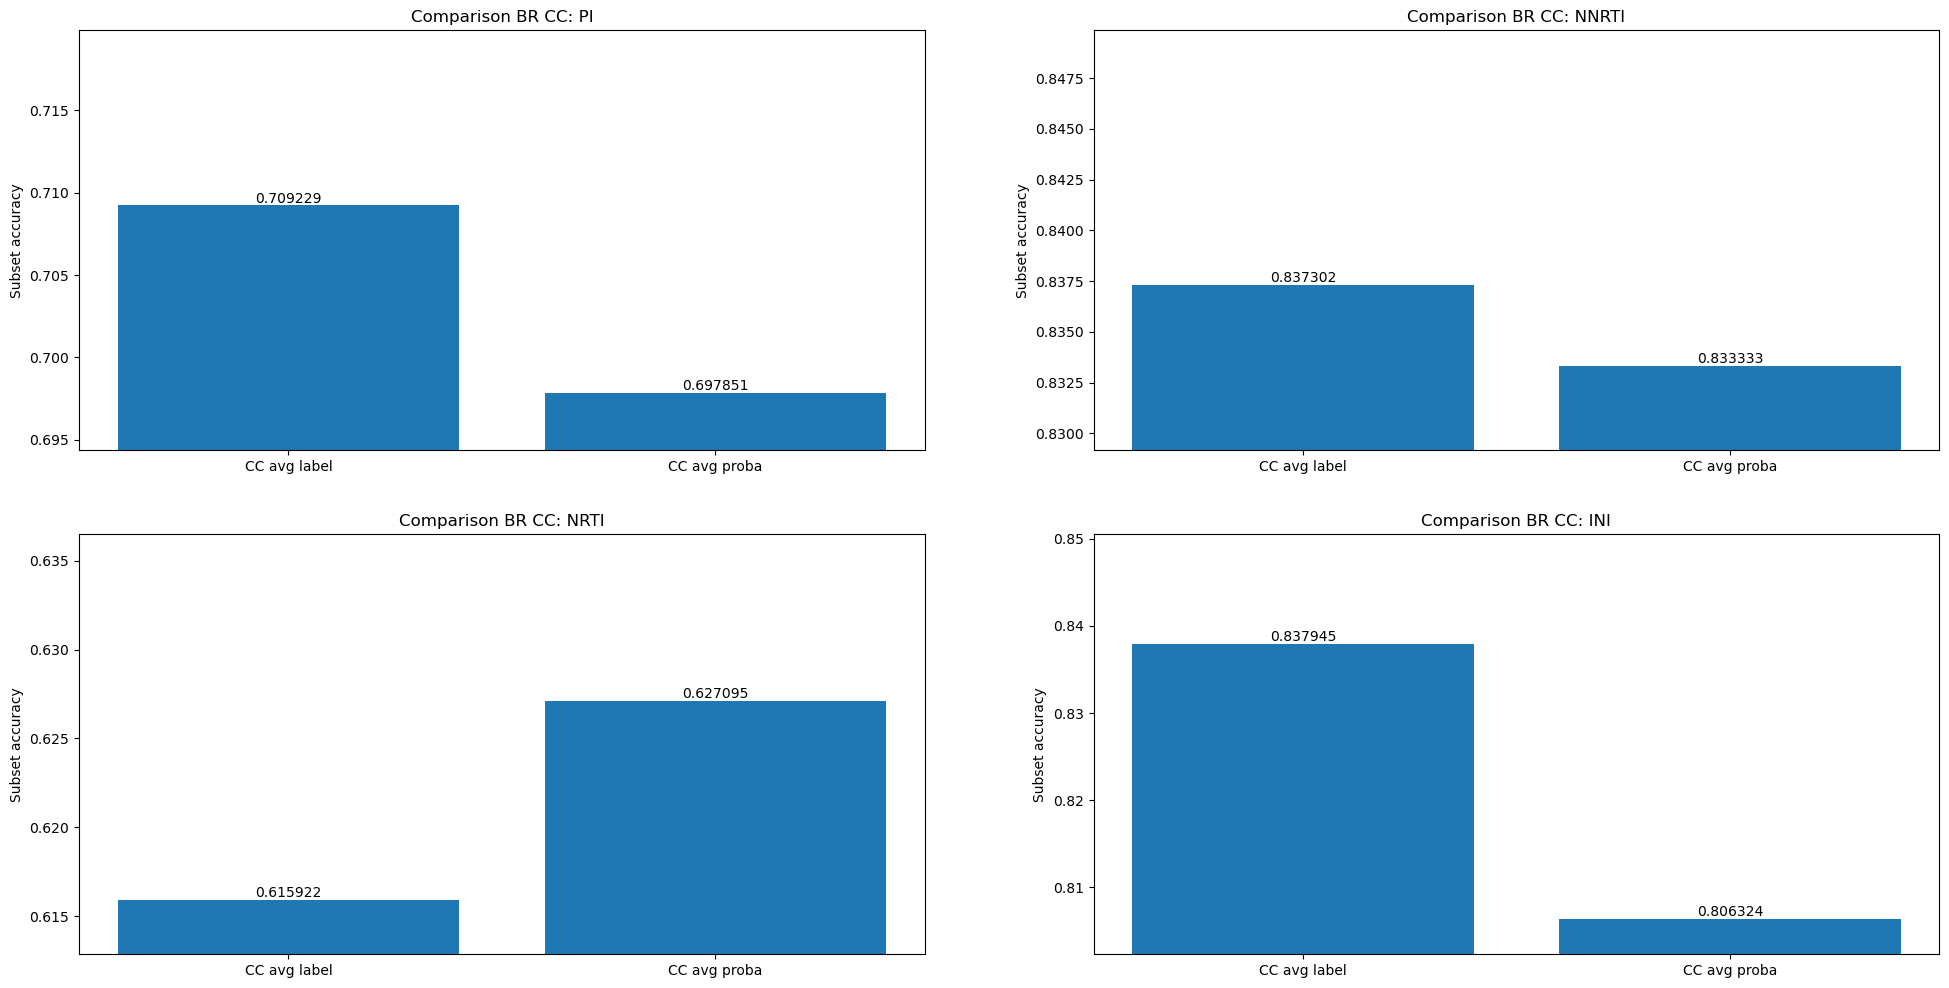

In [7]:
df_ensemble_accs_probas = pd.DataFrame(ensemble_accs_probas)

fig_lab = ["CC avg label", "CC avg proba"]


fig, axs = plt.subplots(2, 2, figsize=(24, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs.columns.values.tolist()):
    p = axs[i].bar(fig_lab, [df_ensemble_accs[drug][4], df_ensemble_accs_probas[drug][4] ])

    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].set_ylabel('Subset accuracy')
    axs[i].set_ylim(max(0, min(df_ensemble_accs[drug][4].min(), df_ensemble_accs_probas[drug][4].min())* 0.995), min(1.0, max(df_ensemble_accs[drug][4].max(), df_ensemble_accs_probas[drug][4].max())  * 1.015))
    axs[i].set_title('Comparison BR CC: ' + drug)

In [11]:
files = ["Binary_Relevance_5_fold_MOC_prediction.csv", "Binary_Relevance_5_fold_homebrew_prediction.csv", "Classifier_Chain_5_fold_homebrew_prediction.csv"]


sub_accs_fold_mean = {}
sub_accs_fold_std = {}

for path in filepath_list:
    acc_list_mean = []
    acc_list_std = []

    for file in files:
        results = pd.read_csv(path + file)

        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.subset_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean.update({path.split("/")[-1].strip("_"):acc_list_mean})
    sub_accs_fold_std.update({path.split("/")[-1].strip("_"):acc_list_std})

df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)

#print(sub_accs)


      True_FPV  True_ATV  True_IDV  True_LPV  True_NFV  True_SQV  True_TPV  \
0          0.0       NaN       0.0       NaN       1.0       0.0       NaN   
1          0.0       NaN       0.0       NaN       1.0       0.0       NaN   
2          1.0       NaN       0.0       NaN       0.0       0.0       NaN   
3          1.0       NaN       1.0       NaN       1.0       0.0       NaN   
4          1.0       NaN       1.0       NaN       1.0       1.0       NaN   
...        ...       ...       ...       ...       ...       ...       ...   
2390       1.0       1.0       1.0       1.0       1.0       1.0       1.0   
2391       1.0       NaN       1.0       1.0       1.0       0.0       NaN   
2392       NaN       1.0       NaN       0.0       NaN       NaN       NaN   
2393       0.0       1.0       1.0       0.0       1.0       1.0       1.0   
2394       1.0       1.0       1.0       1.0       1.0       1.0       0.0   

      True_DRV  Pred_FPV  Pred_ATV  Pred_IDV  Pred_LPV  Pred_NF

In [19]:

filename = "Classifier_Chain_5_folds_ensemble/"

ensemble_accs_mean = {}
ensemble_accs_std = {}

for path in filepath_list:

    chains = os.listdir(path + filename)

    chain_list = []
    chain_acc_list_mean = []
    chain_acc_list_std = []

    true_labels = None

    for chain in chains:
        #print(path+filename+chain)


        results = pd.read_csv(path+filename+chain)

        #print(path+filename+chain)

        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)



        pred_labels = results.filter(regex="Pred_*")

        true_labels = results.filter(regex="True_*")
        #pred_labels = (pred_probas > 0.5) * 1.0

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.subset_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)

        #print(true_labels == true_labels_old)
        #print(pred_labels == pred_labels_old)

        chain_list.append(pred_labels)

        chain_acc_list_mean.append(subs_accs_groups.mean())
        chain_acc_list_std.append(subs_accs_groups.std())
        #chain_acc_list.append(sub_acc)

    columns = chain_list[0].columns.values.tolist()

    ave_chain = (np.median(np.array(chain_list), axis=0) > 0.5) * 1

    ave_chain_df = pd.DataFrame(ave_chain, columns=columns)



    ave_chain_complete = pd.concat([true_labels, ave_chain_df, results["kFolds"]], axis=1)

    #true_labels = ave_chain_df.filter(regex="True_*")
    #pred_labels = (ave_chain_df > 0.5) * 1.0

    print(ave_chain_complete)

    subs_accs_groups = ave_chain_complete.groupby(by="kFolds").apply(lambda x: utils.subset_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)

    #sub_acc = utils.subset_acc(pred_labels, true_labels, nan_mode="ignore")


    chain_acc_list_mean.append(subs_accs_groups.mean())
    chain_acc_list_std.append(subs_accs_groups.std())
    #chain_acc_list.append(sub_acc)

    ensemble_accs_mean.update({path.split("/")[-1].strip("_"):chain_acc_list_mean})
    ensemble_accs_std.update({path.split("/")[-1].strip("_"):chain_acc_list_std})



#df_sub_accs_groups = pd.DataFrame(subs_accs_groups)

df_ensemble_accs_groups_mean = pd.DataFrame(ensemble_accs_mean)
df_ensemble_accs_groups_std = pd.DataFrame(ensemble_accs_std)

#plt.bar(df_sub_accs)

print(df_ensemble_accs_groups_mean)
print(df_ensemble_accs_groups_std)


      True_FPV  True_ATV  True_IDV  True_LPV  True_NFV  True_SQV  True_TPV  \
0          0.0       NaN       0.0       NaN       1.0       0.0       NaN   
1          0.0       NaN       0.0       NaN       1.0       0.0       NaN   
2          1.0       NaN       0.0       NaN       0.0       0.0       NaN   
3          1.0       NaN       1.0       NaN       1.0       0.0       NaN   
4          1.0       NaN       1.0       NaN       1.0       1.0       NaN   
...        ...       ...       ...       ...       ...       ...       ...   
2390       1.0       1.0       1.0       1.0       1.0       1.0       1.0   
2391       1.0       NaN       1.0       1.0       1.0       0.0       NaN   
2392       NaN       1.0       NaN       0.0       NaN       NaN       NaN   
2393       0.0       1.0       1.0       0.0       1.0       1.0       1.0   
2394       1.0       1.0       1.0       1.0       1.0       1.0       0.0   

      True_DRV  Pred_FPV  Pred_ATV  Pred_IDV  Pred_LPV  Pred_NF

In [18]:
print(ensemble_accs_mean)

{'PI': [0.6305376344086022, 0.592156862745098, 0.6117647058823529], 'NNRTI': [0.6305376344086022, 0.592156862745098, 0.6117647058823529], 'NRTI': [0.6305376344086022, 0.592156862745098, 0.6117647058823529], 'INI': [0.6305376344086022, 0.592156862745098, 0.6117647058823529]}


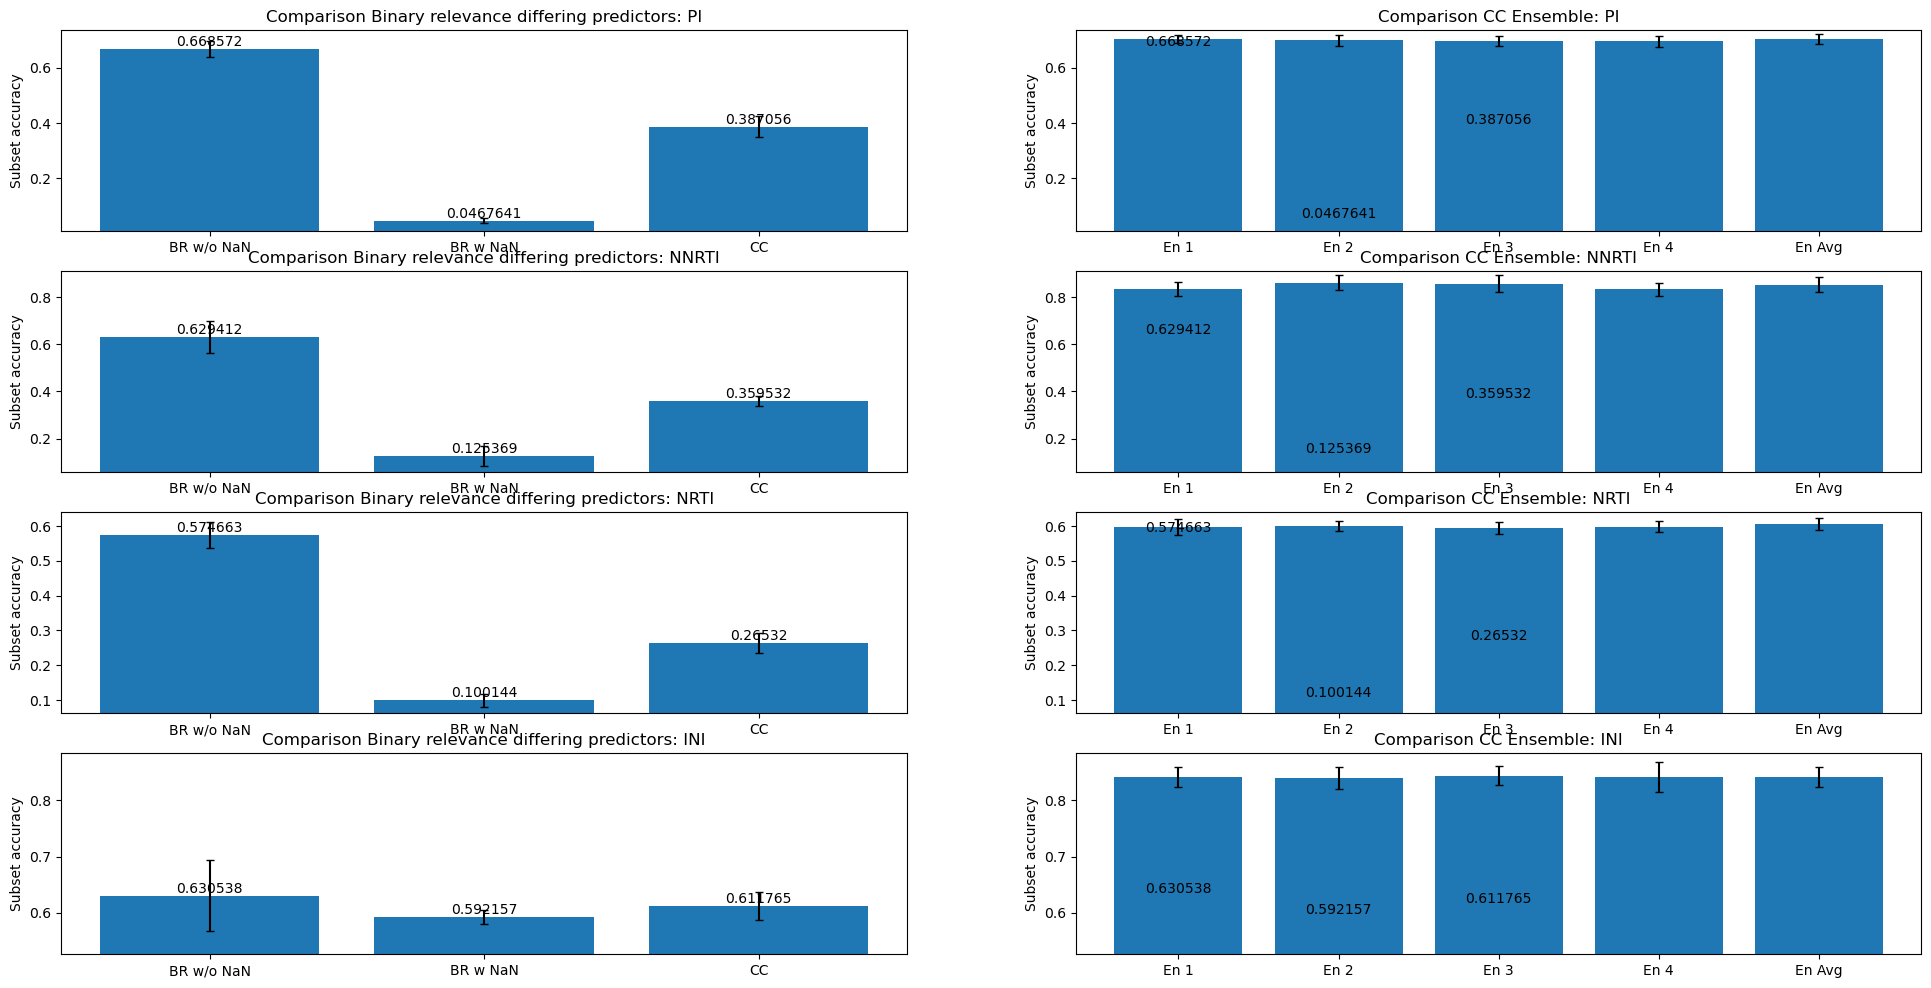

In [20]:

models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC"]

ensemble_labels = ["En 1", "En 2", "En 3", "En 4", "En Avg"]

fig, axs = plt.subplots(4, 2, figsize=(24, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):


    j = 2 * i
    #print(axs[i])
    #print(i)

    p = axs[j].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug])
    axs[j].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[j].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[j].set_ylabel('Subset accuracy')
    axs[j].set_ylim(max(0,min( (df_ensemble_accs_groups_mean[drug].min() - df_ensemble_accs_groups_std[drug].max()), (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) )* 0.995), min(1.0 + df_ensemble_accs_groups_std[drug].max(), max( (df_ensemble_accs_groups_mean[drug].max() + df_ensemble_accs_groups_std[drug].max()) ,  (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max()))* 1.015))
    axs[j].set_title('Comparison Binary relevance differing predictors: ' + drug)




    p2 = axs[j + 1].bar(ensemble_labels, df_ensemble_accs_groups_mean[drug])
    axs[j+1].errorbar(ensemble_labels, df_ensemble_accs_groups_mean[drug], yerr=df_ensemble_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[j+1].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[j+1].set_ylabel('Subset accuracy')
    axs[j+1].set_ylim(max(0,min( (df_ensemble_accs_groups_mean[drug].min() - df_ensemble_accs_groups_std[drug].max()), (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) )* 0.995), min(1.0 + df_ensemble_accs_groups_std[drug].max(), max( (df_ensemble_accs_groups_mean[drug].max() + df_ensemble_accs_groups_std[drug].max()) ,  (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max()))* 1.015))
    axs[j+1].set_title('Comparison CC Ensemble: ' + drug)


#plt.savefig("../figures/BR_CC_kfold_model_comparison.png")

    #plt.savefig("../figures/" + filepath_ml.split("/")[-1].split("_")[0] + "_Multilabel_Comparison.png")
